In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

import warnings
warnings.filterwarnings("ignore")

/kaggle/input/nse-stock-historical-price-data/nse_all_stock_data (1).csv


In [2]:
data = pd.read_csv(
    "/kaggle/input/nse-stock-historical-price-data/nse_all_stock_data (1).csv",
    index_col="Date",
    parse_dates=True
)

data.head()

,RELIANCE,TCS,HDFCBANK,ICICIBANK,BHARTIARTL,SBIN,INFY,LICI,ITC,HINDUNILVR,...,COOLCAPS,ALLETEC,20MICRONS,VIKASECO,ORIENTBELL,DONEAR,CAREERP,INTLCONV,SHREEPUSHK,PRITIKAUTO
Date,,,,,,,,,,,,,,,,,,,,,
1991-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print("Shape:", data.shape)

data.info()

data.describe().T

Shape: (8470, 1417)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8470 entries, 1991-01-02 to 2024-07-05
Columns: 1417 entries, RELIANCE to PRITIKAUTO
dtypes: float64(1417)
memory usage: 91.6 MB


,count,mean,std,min,25%,50%,75%,max
RELIANCE,7160.0,605.661551,747.797566,10.975116,48.913174,388.722839,635.261246,3177.250000
TCS,5436.0,1221.558660,1171.494557,35.474998,240.846245,778.625000,1968.299988,4219.250000
HDFCBANK,7163.0,437.622147,528.539886,2.435000,24.672500,172.225006,718.825012,1768.650024
ICICIBANK,5465.0,296.793689,265.540644,20.100000,132.781815,203.554550,343.549988,1233.400024
BHARTIARTL,5465.0,359.974920,241.483014,9.350544,266.952423,319.000000,391.145660,1475.800049
...,...,...,...,...,...,...,...,...
DONEAR,4323.0,49.874282,45.585231,8.900000,21.000000,31.750000,61.324999,236.149994
CAREERP,3389.0,155.291620,80.022231,51.150002,109.000000,132.750000,166.899994,660.000000
INTLCONV,692.0,71.400780,13.448132,47.750000,58.799999,70.924999,81.787500,119.900002
SHREEPUSHK,2173.0,171.467658,54.506985,59.349998,122.400002,178.000000,210.949997,332.000000


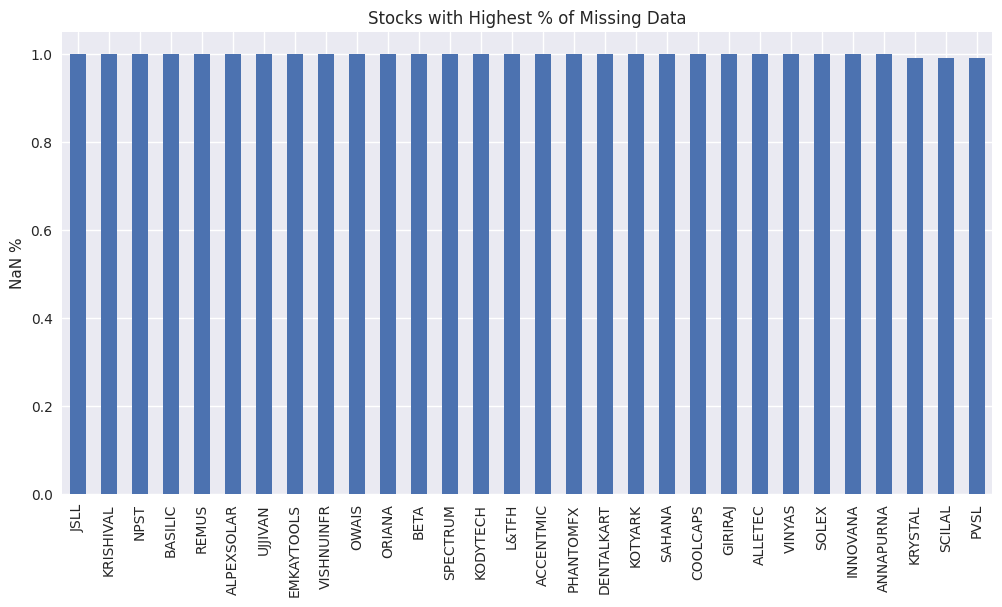

In [4]:
nan_pct = data.isna().mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
nan_pct.head(30).plot(kind="bar")
plt.title("Stocks with Highest % of Missing Data")
plt.ylabel("NaN %")
plt.show()

In [5]:
threshold = 0.8   # keep stocks with >=70% data

valid_cols = data.columns[data.notna().mean() > threshold]

data_clean = data[valid_cols]

print("Original stocks:", data.shape[1])
print("Remaining stocks:", data_clean.shape[1])

Original stocks: 1417
Remaining stocks: 64


In [6]:
data_clean = data_clean.ffill()

In [7]:
print("Remaining NaNs:", data_clean.isna().sum().sum())

Remaining NaNs: 83018


In [8]:
missing = data.isna().sum().sort_values(ascending=False)

missing.head(20)

JSLL          8470
KRISHIVAL     8470
NPST          8470
BASILIC       8470
REMUS         8470
ALPEXSOLAR    8470
UJJIVAN       8470
EMKAYTOOLS    8470
VISHNUINFR    8470
OWAIS         8470
ORIANA        8470
BETA          8470
SPECTRUM      8470
KODYTECH      8470
L&TFH         8470
ACCENTMIC     8470
PHANTOMFX     8470
DENTALKART    8470
KOTYARK       8470
SAHANA        8470
dtype: int64

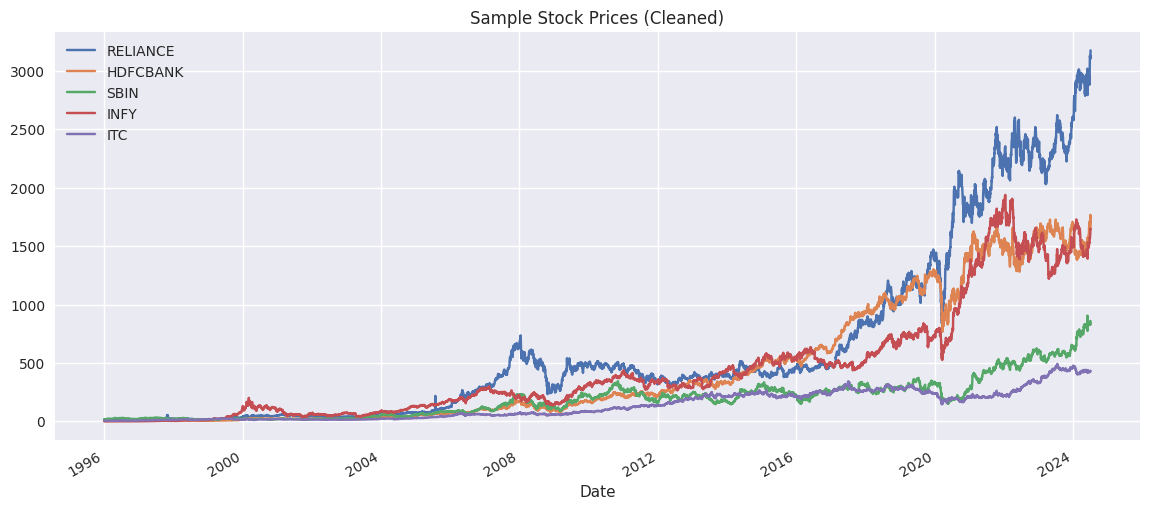

In [9]:
stocks = data_clean.columns[:5]

data_clean[stocks].plot(figsize=(14,6))
plt.title("Sample Stock Prices (Cleaned)")
plt.show()

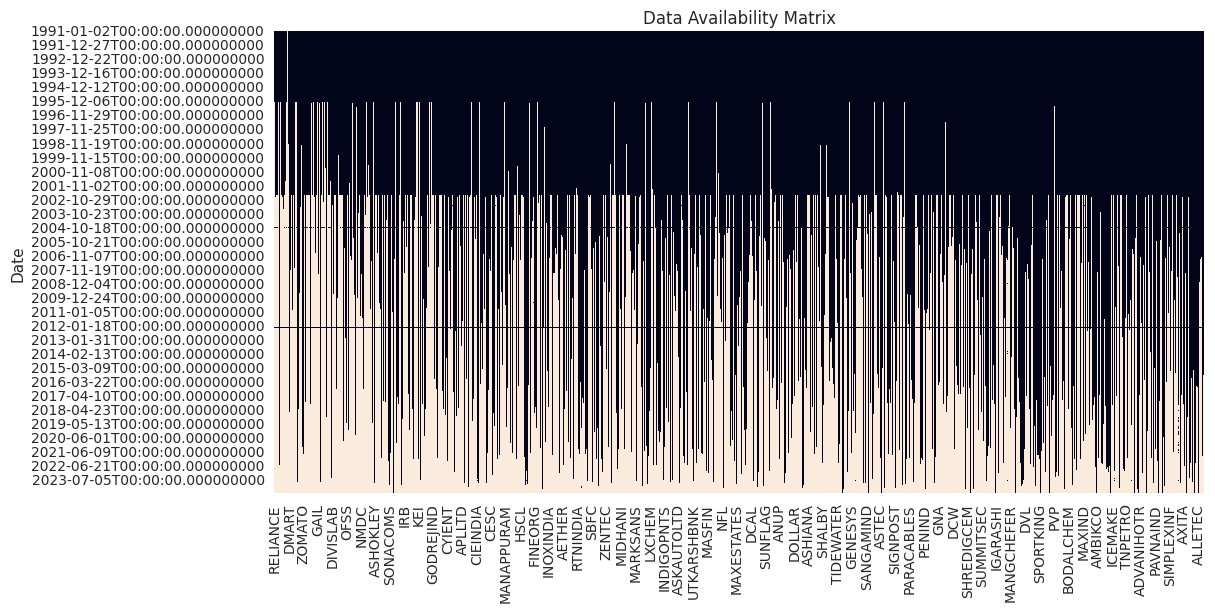

In [10]:
plt.figure(figsize=(12,6))
sns.heatmap(data.notna(), cbar=False)
plt.title("Data Availability Matrix")
plt.show()

In [11]:
data_2002 = data.loc["2002":"2024"]

In [12]:
print(data.shape)
print(data_2002.shape)

(8470, 1417)
(5601, 1417)


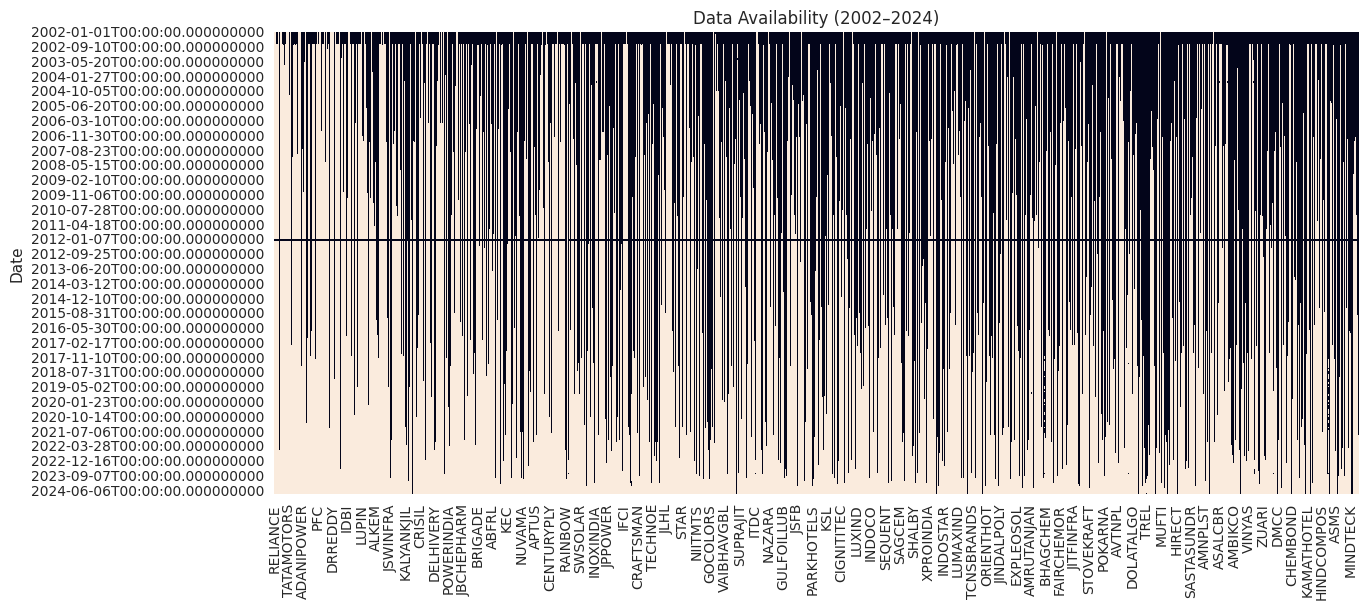

In [13]:
plt.figure(figsize=(14,6))

sns.heatmap(data_2002.notna().iloc[::20], cbar=False)

plt.title("Data Availability (2002–2024)")
plt.show()

In [14]:
coverage = data_2002.notna().mean()

valid_cols = coverage[coverage > 0.6].index

data_clean = data_2002[valid_cols]

print("Remaining stocks:", len(valid_cols))

Remaining stocks: 756


In [15]:
for col in data_clean.columns:
    
    first_valid = data_clean[col].first_valid_index()
    
    data_clean.loc[first_valid:, col] = data_clean.loc[first_valid:, col].ffill()

In [16]:
data_clean.isna().sum().sum()

502033

In [17]:
returns = data_clean.pct_change().dropna()

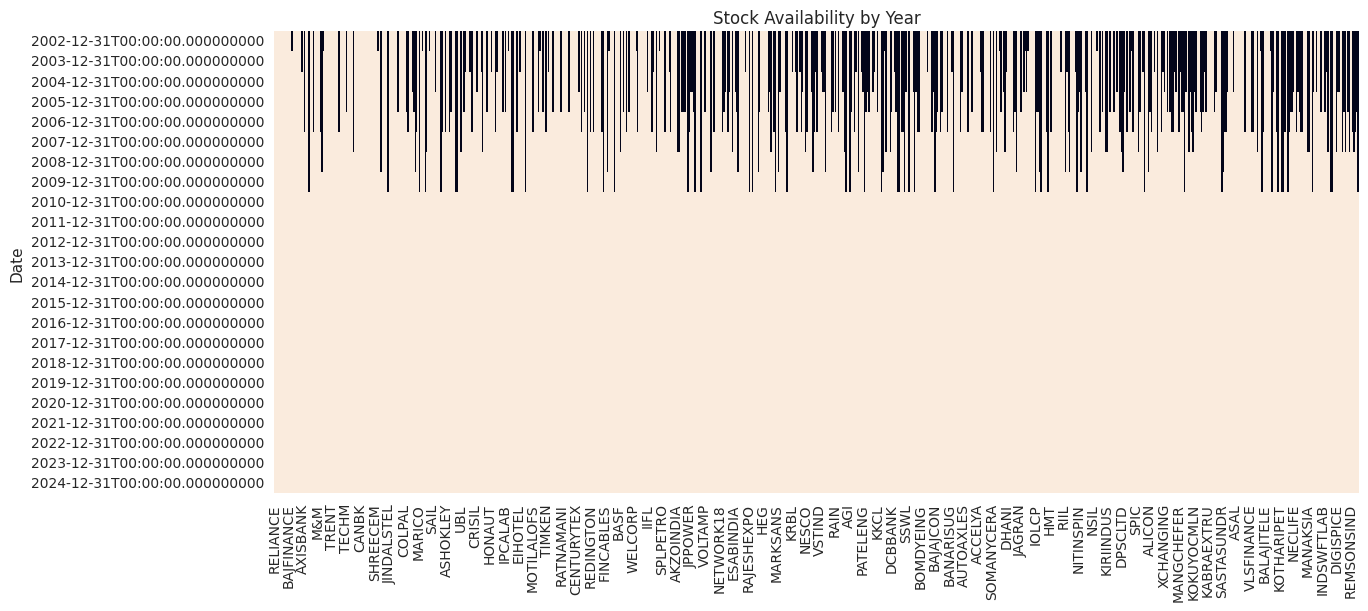

In [18]:
plt.figure(figsize=(14,6))

sns.heatmap(data_clean.resample("Y").mean().notna(), cbar=False)

plt.title("Stock Availability by Year")
plt.show()

<Axes: >

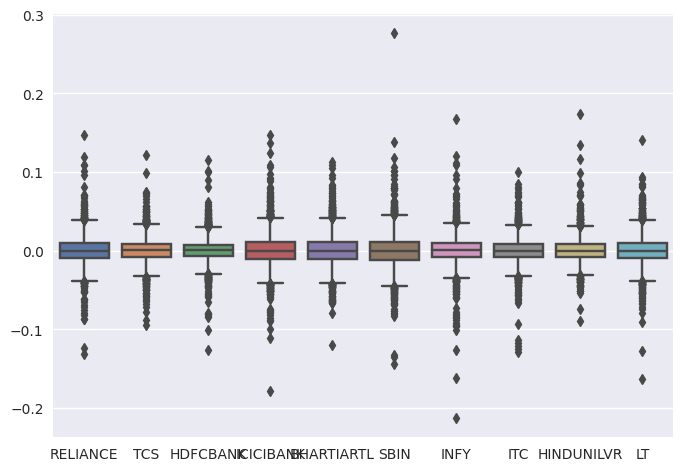

In [19]:
sns.boxplot(data=returns.iloc[:, :10])

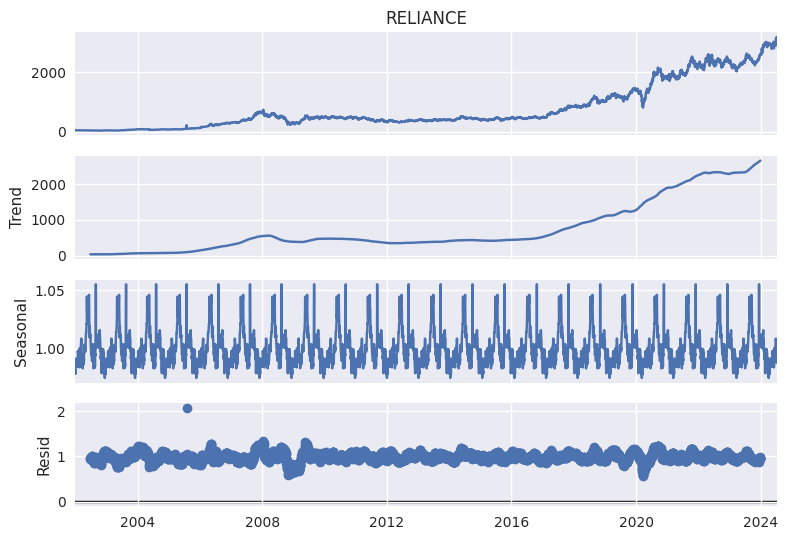

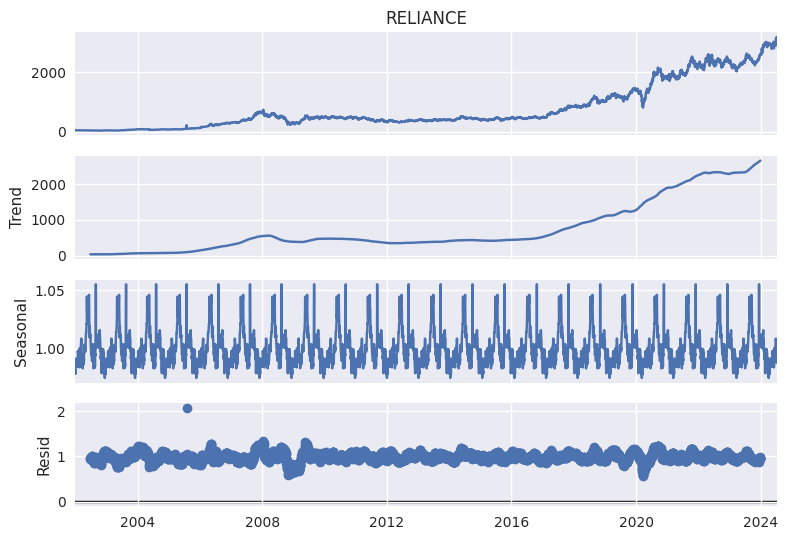

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

series = data_clean["RELIANCE"]

result = seasonal_decompose(series, model="multiplicative", period=252)

result.plot()

<Figure size 1000x400 with 0 Axes>

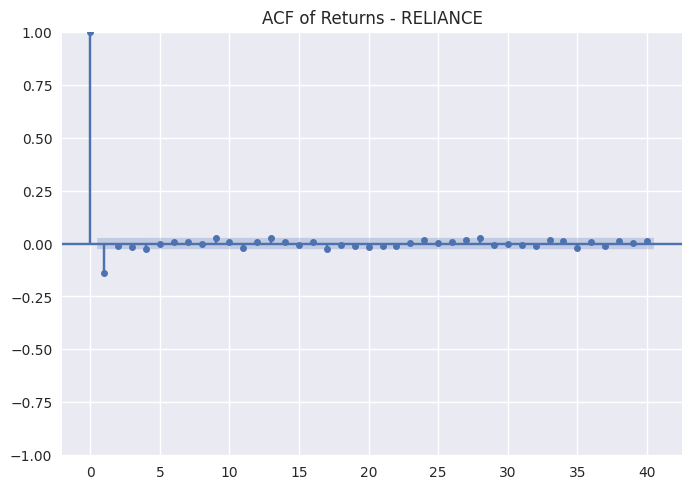

In [21]:
stock = "RELIANCE"

series = data_clean[stock]
returns_series = series.pct_change().dropna()

plt.figure(figsize=(10,4))
plot_acf(returns_series, lags=40)
plt.title(f"ACF of Returns - {stock}")
plt.show()

<Figure size 1000x400 with 0 Axes>

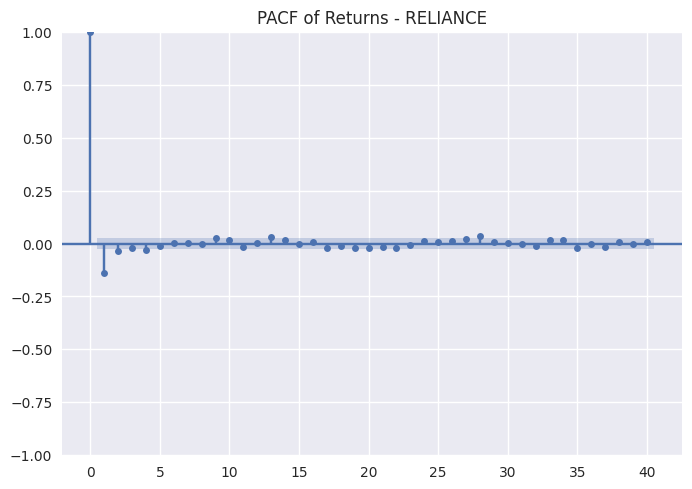

In [22]:
plt.figure(figsize=(10,4))
plot_pacf(returns_series, lags=40)
plt.title(f"PACF of Returns - {stock}")
plt.show()

In [23]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(series.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 1.6994268939766306
p-value: 0.9981272174058847


In [24]:
result = adfuller(returns_series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

# p > 0.05	non-stationary
# p < 0.05	stationary 

ADF Statistic: -41.15163526606555
p-value: 0.0


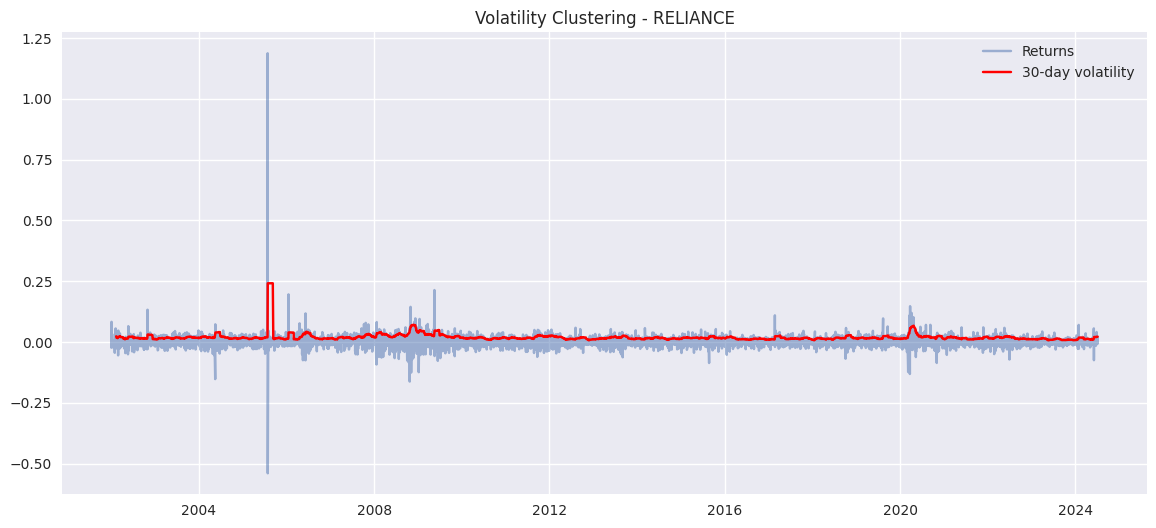

In [25]:
rolling_vol = returns_series.rolling(30).std()

plt.figure(figsize=(14,6))

plt.plot(returns_series, alpha=0.5, label="Returns")
plt.plot(rolling_vol, color="red", label="30-day volatility")

plt.legend()
plt.title(f"Volatility Clustering - {stock}")
plt.show()

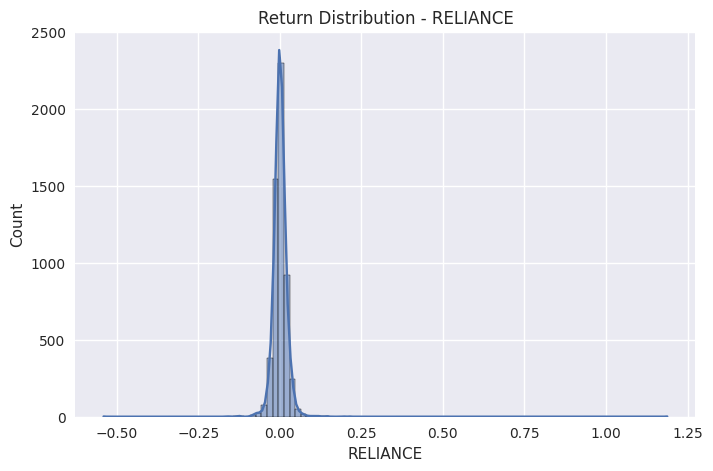

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(returns_series, bins=100, kde=True)

plt.title(f"Return Distribution - {stock}")
plt.show()

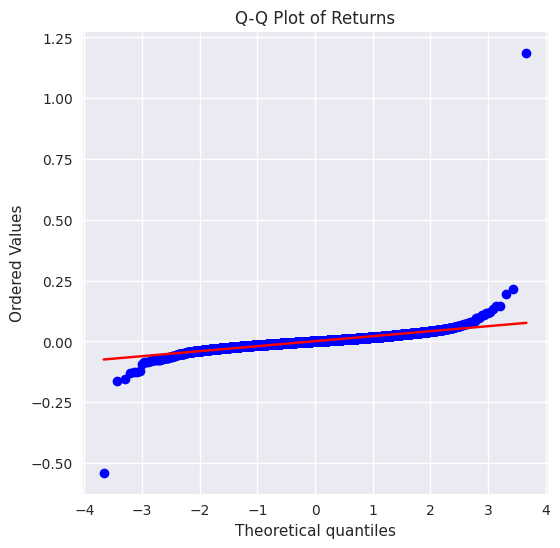

In [27]:
import scipy.stats as stats

plt.figure(figsize=(6,6))

stats.probplot(returns_series, dist="norm", plot=plt)

plt.title("Q-Q Plot of Returns")
plt.show()

In [28]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(returns_series)

print("ARCH p-value:", arch_test[1])

# p < 0.05
#volatility clustering present

ARCH p-value: 2.7531454152843126e-43


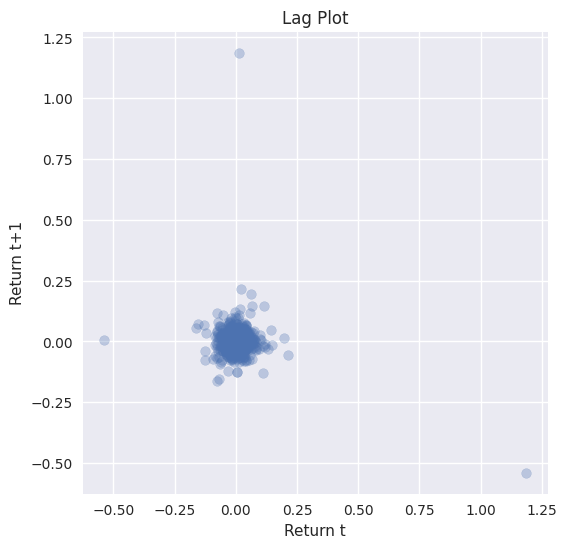

In [29]:
plt.figure(figsize=(6,6))

plt.scatter(returns_series[:-1], returns_series[1:], alpha=0.3)

plt.xlabel("Return t")
plt.ylabel("Return t+1")

plt.title("Lag Plot")
plt.show()

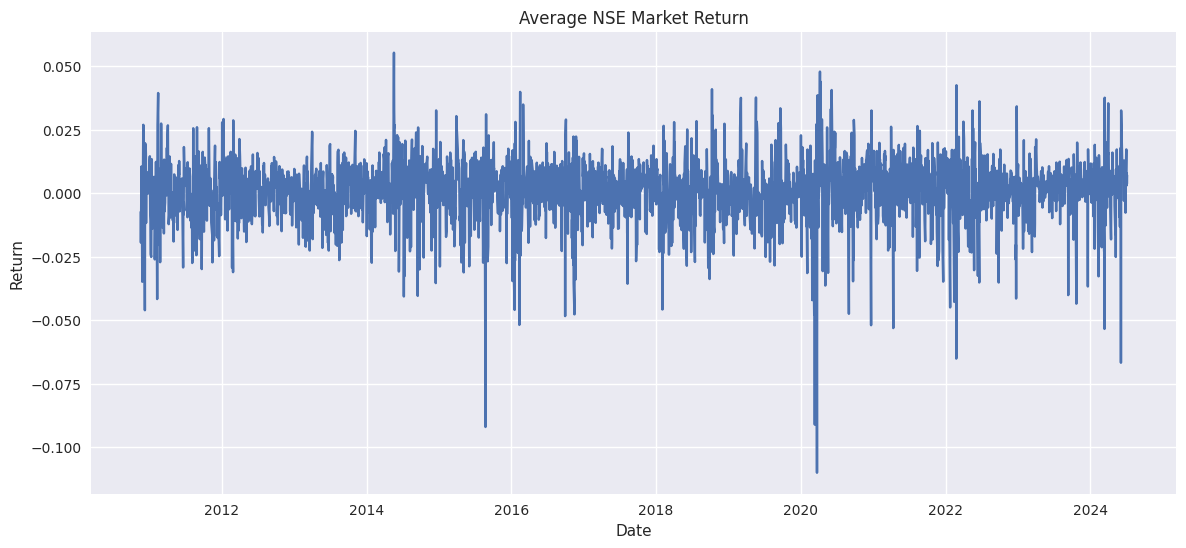

In [30]:
market_return = returns.mean(axis=1)

plt.figure(figsize=(14,6))

plt.plot(market_return)

plt.title("Average NSE Market Return")
plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

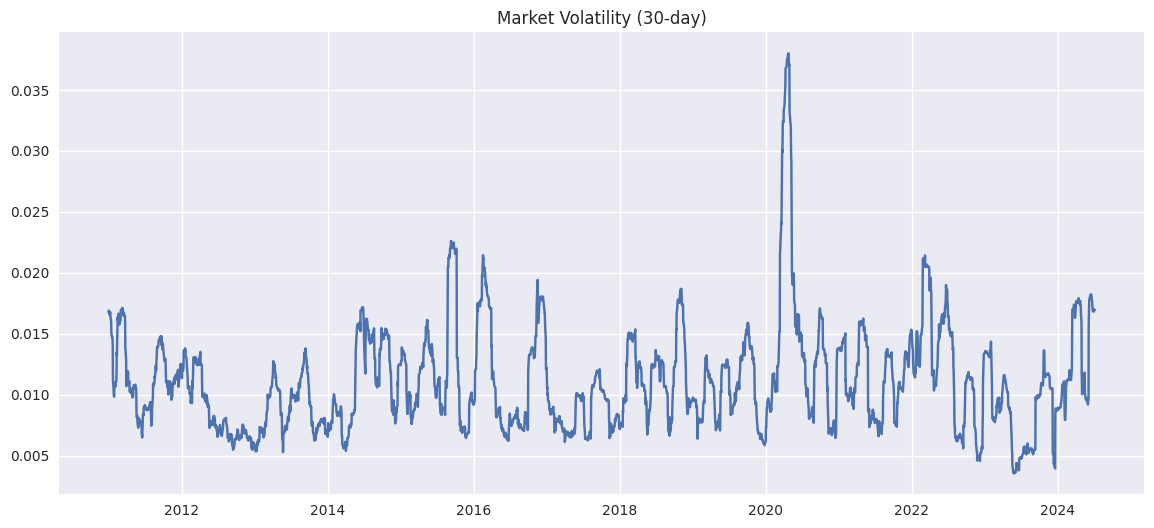

In [31]:
market_vol = market_return.rolling(30).std()

plt.figure(figsize=(14,6))

plt.plot(market_vol)

plt.title("Market Volatility (30-day)")
plt.show()

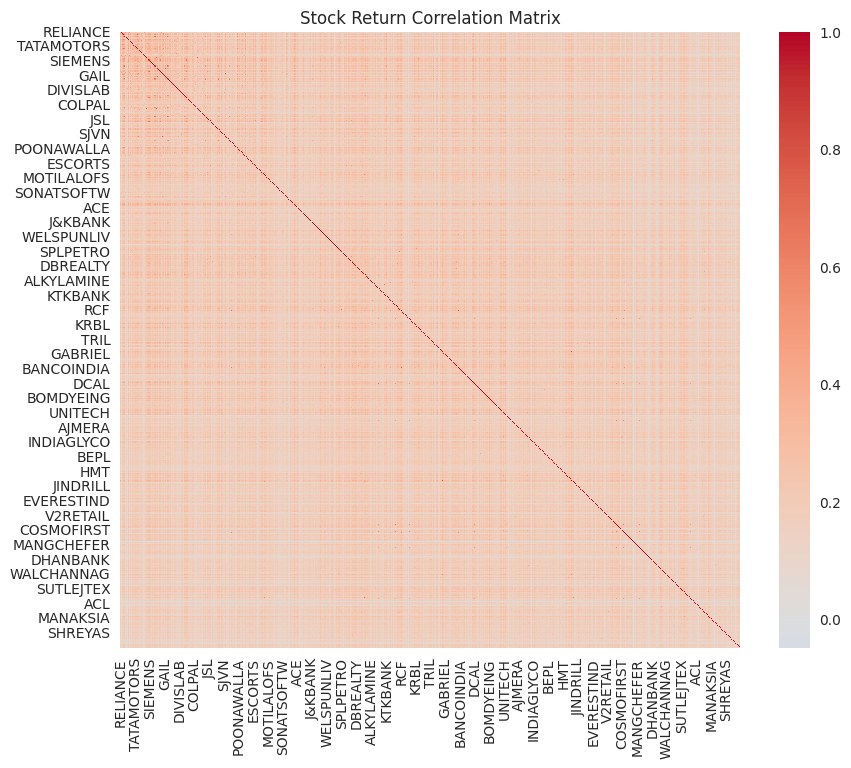

In [32]:
corr = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr, cmap="coolwarm", center=0)

plt.title("Stock Return Correlation Matrix")

plt.show()

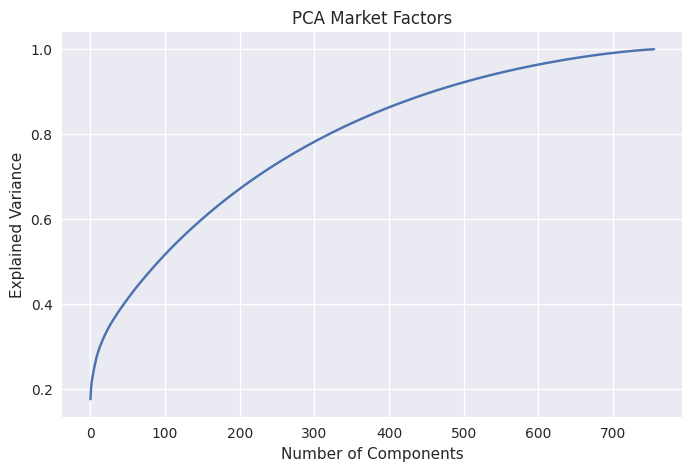

In [33]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(returns.fillna(0))

plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_))

plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")

plt.title("PCA Market Factors")

plt.show()

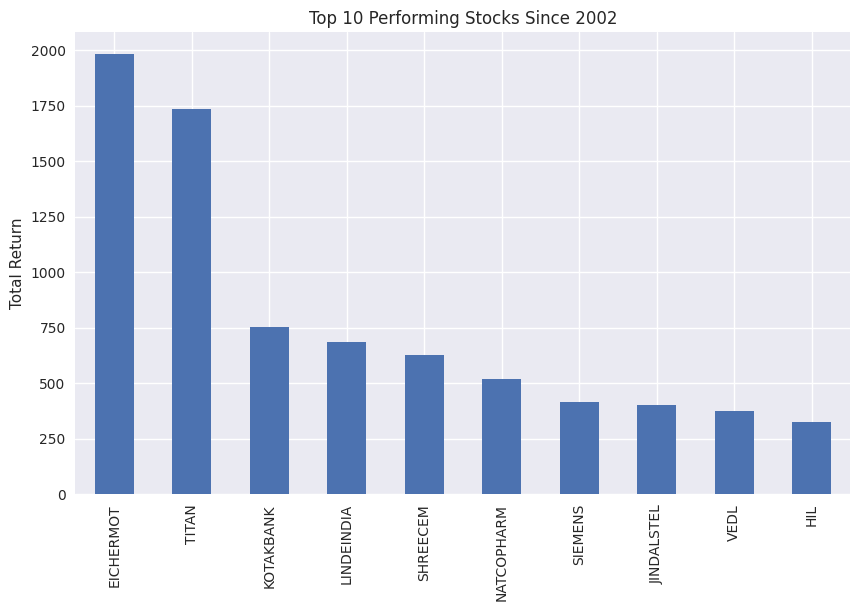

In [34]:
total_return = data_clean.iloc[-1] / data_clean.iloc[0] - 1

top_stocks = total_return.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

top_stocks.plot(kind="bar")

plt.title("Top 10 Performing Stocks Since 2002")

plt.ylabel("Total Return")

plt.show()

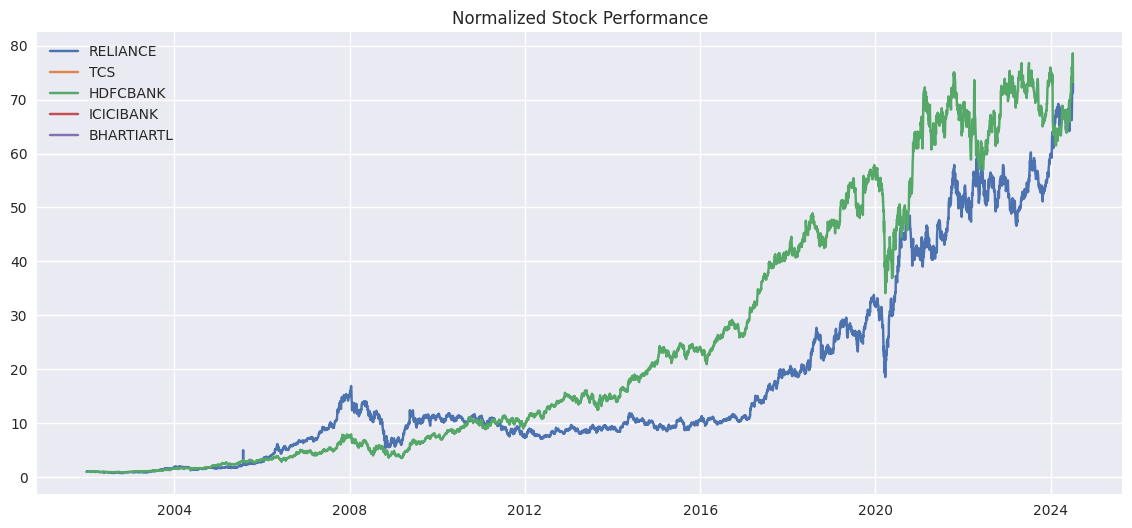

In [35]:
normalized = data_clean / data_clean.iloc[0]

sample = normalized.iloc[:, :5]

plt.figure(figsize=(14,6))

for col in sample.columns:
    plt.plot(sample.index, sample[col], label=col)

plt.legend()

plt.title("Normalized Stock Performance")

plt.show()

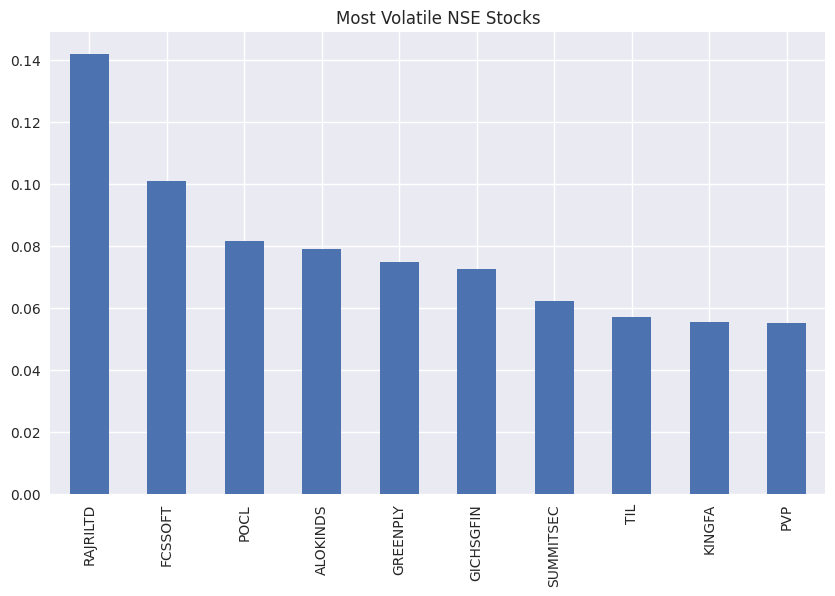

In [36]:
volatility = returns.std().sort_values(ascending=False)

plt.figure(figsize=(10,6))

volatility.head(10).plot(kind="bar")

plt.title("Most Volatile NSE Stocks")

plt.show()

This analysis highlights key patterns in financial time series such as trends, 
volatility, and potential seasonality in market behavior.

Key findings:
- The time series shows periods of growth and contraction, reflecting market cycles.
- Volatility is not constant and varies across time.
- Short-term fluctuations may differ significantly from long-term trends.

Business implications:
- Forecasting models should incorporate both trend and volatility dynamics.
- Investment decisions should consider both:
    - expected returns (trend)
    - risk (volatility)
- Feature engineering (e.g., rolling averages, lag variables) can significantly improve predictive performance.

Conclusion:
Understanding both trend and variability in financial time series enables better 
decision-making in areas such as portfolio allocation, trading strategies, and risk control.